In [ ]:
Modelos com coeficiente grande terão variância maior

principio do encolhimento - escolha o parâmettro

Erro quadrático regularizado - Ridge Regression
1 - controle da variância e viés
2 - restrição no tamanho dos parâmetros - Lasso Regression
3 - regularização do tikhonov (sacou que em vez de minimizar o erro quadrático, você poderia fazer isso e adicionar a função do parâmetro)

palavra-chave: regularização

a regularização permite que você faça uma regrsssão mesmo com um número de dados menor do que o número de parâmetros

problemas

1- Erro de comparação multipla (comparar muitos modelos pode ter a chance muito grande que haja um erro de qual é o melhor modelo) - se você compara muto a chamce de você errar aumenta muito
2- problema compuational

O LASSO resolve esses dois problemas ao mesmo tempo

reduzir o espaço de parametro é o erro quadrático + regularização

quanto maior o lambida o número de parametros vai reduzindo, ou seja faz com que mais coefientes sejam nulos

definir bem o problema


dúvidas

Cross validation?

 As equações de custo para regularização no aprendizado de máquina geralmente pegam a função de custo original do modelo (como o Erro Quadrático Médio para regressão) e adicionam um termo de penalidade baseado nos coeficientes do modelo.

Aqui estão as equações de custo para algumas regularizações comuns:

1.  **Regressão Linear sem Regularização (Erro Quadrático Médio - MSE):**
    Esta é a função de custo base antes de adicionar qualquer termo de regularização.
    $J(\beta) = MSE(\beta) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 = \frac{1}{N} \sum_{i=1}^{N} (y_i - (\beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}))^2$
    Onde:
    *   $J(\beta)$ é a função de custo a ser minimizada.
    *   $N$ é o número de observações.
    *   $y_i$ é o valor real para a i-ésima observação.
    *   $\hat{y}_i$ é o valor previsto para a i-ésima observação.
    *   $\beta_0$ é o intercepto.
    *   $\beta_j$ são os coeficientes para as variáveis independentes $x_j$.
    *   $p$ é o número de variáveis independentes.

2.  **Regularização L2 (Ridge Regression ou Regularização de Tikhonov):**
    Adiciona a penalidade L2 (soma dos quadrados dos coeficientes) à função de custo.
    $J_{Ridge}(\beta) = MSE(\beta) + \alpha \sum_{j=1}^{p} \beta_j^2$
    Onde:
    *   $J_{Ridge}(\beta)$ é a função de custo com regularização L2.
    *   $MSE(\beta)$ é o Erro Quadrático Médio.
    *   $\alpha$ (alpha) é o parâmetro de regularização ($\alpha \ge 0$). Ele controla a força da penalidade. Note que a penalidade geralmente não inclui o intercepto ($\beta_0$).

3.  **Regularização L1 (Lasso Regression):**
    Adiciona a penalidade L1 (soma dos valores absolutos dos coeficientes) à função de custo.
    $J_{Lasso}(\beta) = MSE(\beta) + \alpha \sum_{j=1}^{p} |\beta_j|$
    Onde:
    *   $J_{Lasso}(\beta)$ é a função de custo com regularização L1.
    *   $MSE(\beta)$ é o Erro Quadrático Médio.
    *   $\alpha$ (alpha) é o parâmetro de regularização ($\alpha \ge 0$). Ele controla a força da penalidade. Similar à Ridge, a penalidade geralmente não inclui o intercepto ($\beta_0$).

4.  **Elastic Net Regularization:**
    Combina as penalidades L1 e L2.
    $J_{ElasticNet}(\beta) = MSE(\beta) + \alpha_1 \sum_{j=1}^{p} |\beta_j| + \alpha_2 \sum_{j=1}^{p} \beta_j^2$
    Onde:
    *   $J_{ElasticNet}(\beta)$ é a função de custo com regularização Elastic Net.
    *   $MSE(\beta)$ é o Erro Quadrático Médio.
    *   $\alpha_1$ e $\alpha_2$ são parâmetros de regularização ($\alpha_1 \ge 0, \alpha_2 \ge 0$) que controlam a força das penalidades L1 e L2, respectivamente. Frequentemente, é usado um único parâmetro $\alpha$ e um rácio $l1\_ratio$ para combinar as penalidades: $J_{ElasticNet}(\beta) = MSE(\beta) + \alpha \times (l1\_ratio \times \sum |\beta_j| + (1 - l1\_ratio) \times \sum \beta_j^2)$.

Essas equações mostram como o termo de regularização é adicionado à função de custo base para penalizar a complexidade do modelo (representada pelos coeficientes) durante o processo de minimização.

O erro quadrático regularizado, como o usado na Ridge Regression, adiciona um termo de penalidade à função de erro quadrático usual. O objetivo é evitar que os coeficientes do modelo se tornem muito grandes, o que pode levar ao overfitting.

Na Ridge Regression, a função que minimizamos é:

Erro Quadrático Regularizado = Erro Quadrático (MSE) + $\alpha \times \sum_{i=1}^{n} \beta_i^2$

Onde:

*   **Erro Quadrático (MSE)**: É a soma dos quadrados das diferenças entre os valores reais e os valores previstos.
*   **$\alpha$ (alpha)**: É o parâmetro de regularização. Ele controla a intensidade da penalidade. Um valor maior de $\alpha$ resulta em maior encolhimento dos coeficientes.
*   **$\sum_{i=1}^{n} \beta_i^2$**: É a soma dos quadrados dos coeficientes do modelo ($\beta_i$ representa cada coeficiente). Este é o termo de penalidade L2.

Em resumo, você "faz" um erro quadrático regularizado ao definir uma função de perda que inclui tanto o erro quadrático usual quanto um termo de penalidade nos coeficientes, e então treina seu modelo para minimizar essa função de perda.

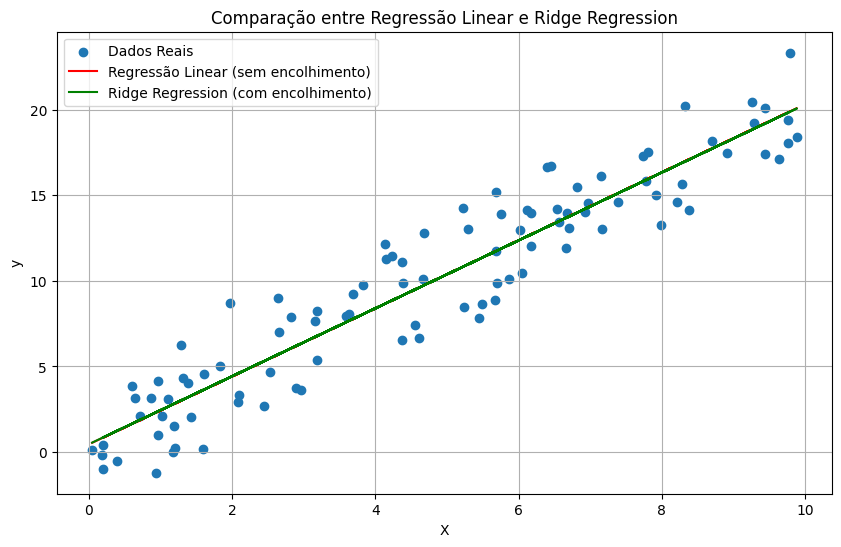

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some sample data
np.random.seed(0)
X = np.random.rand(100, 1) * 10
y = 2 * X.squeeze() + np.random.randn(100) * 2

# Fit a simple linear regression model (no shrinkage)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)

# Fit a Ridge regression model (L2 shrinkage)
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)  # alpha is the shrinkage parameter
ridge.fit(X, y)
y_pred_ridge = ridge.predict(X)

# Plot the data and the models
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Dados Reais')
plt.plot(X, y_pred_lr, color='red', label='Regressão Linear (sem encolhimento)')
plt.plot(X, y_pred_ridge, color='green', label='Ridge Regression (com encolhimento)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparação entre Regressão Linear e Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()

### Exemplo Visual de Regularização de Tikhonov (Ridge Regression)

O gráfico abaixo ilustra a diferença entre uma Regressão Linear simples e uma Regressão Ridge (Regularização de Tikhonov). Note como a linha da Ridge Regression é um pouco mais "achatada" devido ao encolhimento dos coeficientes.

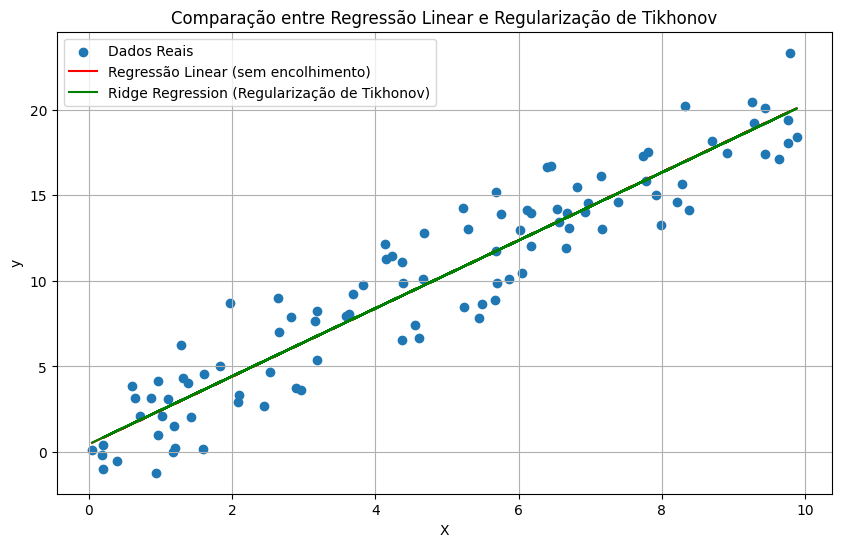

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some sample data
np.random.seed(0)
X = np.random.rand(100, 1) * 10
y = 2 * X.squeeze() + np.random.randn(100) * 2

# Fit a simple linear regression model (no shrinkage)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)

# Fit a Ridge regression model (L2 shrinkage)
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)  # alpha is the shrinkage parameter (parametro de Tikhonov)
ridge.fit(X, y)
y_pred_ridge = ridge.predict(X)

# Plot the data and the models
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Dados Reais')
plt.plot(X, y_pred_lr, color='red', label='Regressão Linear (sem encolhimento)')
plt.plot(X, y_pred_ridge, color='green', label='Ridge Regression (Regularização de Tikhonov)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparação entre Regressão Linear e Regularização de Tikhonov')
plt.legend()
plt.grid(True)
plt.show()

A teoria por trás de como minimizar o erro quadrático quando impomos a restrição de que os coeficientes do modelo devem ser positivos pode ser formulada como um problema de otimização convexa com restrições de desigualdade. Para um modelo de regressão linear simples com um único coeficiente $\beta_1$ e um intercepto $\beta_0$, a função que queremos minimizar é o Erro Quadrático Médio (MSE):

$MSE(\beta_0, \beta_1) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (\beta_0 + \beta_1 x_i))^2$

Estamos sujeitos à restrição $\beta_1 \ge 0$.

Em casos mais gerais com múltiplos coeficientes $\beta = [\beta_1, \beta_2, ..., \beta_p]$, a função a minimizar continua sendo o MSE, mas os coeficientes são um vetor, e a restrição é que todos os elementos desse vetor de coeficientes (exceto o intercepto, que geralmente não tem essa restrição) devem ser não negativos:

$MSE(\beta_0, \beta) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (\beta_0 + X_i \beta))^2$

Sujeito a $\beta_j \ge 0$ para $j = 1, 2, ..., p$.

A minimização dessa função sujeita a essas restrições não pode ser feita simplesmente calculando as derivadas parciais e igualando a zero, como na regressão linear ordinária (sem restrições), porque a solução ótima pode estar na fronteira da região permitida (onde um ou mais coeficientes são exatamente zero).

Métodos comuns para resolver esse tipo de problema incluem:

1.  **Métodos de Otimização Iterativos:** Algoritmos como o Gradiente Projetado (Projected Gradient Descent) ou o L-BFGS-B podem ser usados. Esses algoritmos começam com uma estimativa inicial para os coeficientes e iterativamente ajustam esses valores para diminuir o MSE, mas a cada passo, eles garantem que as restrições ($\beta_j \ge 0$) sejam satisfeitas. Se um passo de atualização levaria um coeficiente a ser negativo, ele é "projetado" de volta para zero.

2.  **Programação Quadrática:** O problema de minimizar o MSE com restrições lineares (como $\beta_j \ge 0$) pode ser reformulado como um problema de programação quadrática (QP). Existem algoritmos e solvers especializados para resolver QPs de forma eficiente. A função objetivo é quadrática (devido ao termo quadrático no MSE) e as restrições são lineares.

3.  **Métodos Ativos de Conjunto (Active Set Methods):** Esses métodos funcionam mantendo um "conjunto ativo" de restrições que se acredita serem ativas na solução ótima (ou seja, onde as restrições são satisfeitas com igualdade, como $\beta_j = 0$). O algoritmo resolve o problema de otimização sem restrições para as variáveis que não estão no conjunto ativo e depois verifica se as restrições violadas podem ser adicionadas ao conjunto ativo, ou se as restrições no conjunto ativo podem ser removidas.

Em essência, a teoria por trás da minimização do erro quadrático com coeficientes positivos envolve técnicas de otimização que conseguem lidar com restrições de desigualdade. Elas garantem que a solução encontrada não apenas minimize o erro, mas também respeite a condição de que os coeficientes não sejam negativos. Diferente da regressão linear comum, onde a solução tem uma forma fechada (a equação normal), a regressão com restrições geralmente requer métodos iterativos ou solvers de otimização.

Coeficiente (com restrição positiva): 2.86
Intercepto (com restrição positiva): 5.65


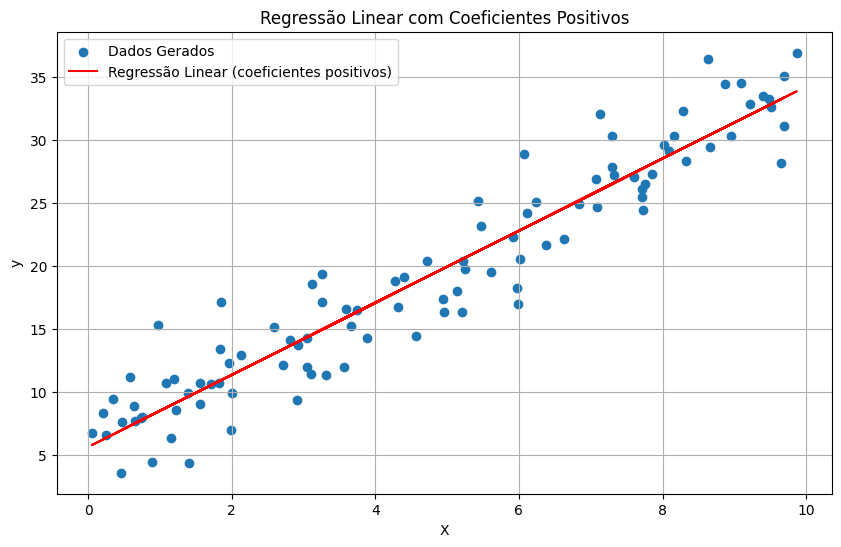

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Gerar dados de exemplo com uma relação positiva
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 3 * X.squeeze() + np.random.randn(100) * 3 + 5 # Adicionando um intercepto e ruído

# Criar e ajustar o modelo de Regressão Linear com coeficientes positivos
# O parâmetro positive=True impõe a restrição de coeficientes positivos
lr_positive = LinearRegression(positive=True)
lr_positive.fit(X, y)

print(f"Coeficiente (com restrição positiva): {lr_positive.coef_[0]:.2f}")
print(f"Intercepto (com restrição positiva): {lr_positive.intercept_:.2f}")

# Plotar os dados e a linha de regressão
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Dados Gerados')
plt.plot(X, lr_positive.predict(X), color='red', label='Regressão Linear (coeficientes positivos)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regressão Linear com Coeficientes Positivos')
plt.legend()
plt.grid(True)
plt.show()

A expressão "erro quadrático + I(a)" em aprendizado de máquina geralmente representa uma **função de perda regularizada**.

Vamos quebrar a expressão:

*   **Erro Quadrático:** Refere-se ao Erro Quadrático Médio (MSE - Mean Squared Error) ou Soma dos Erros Quadráticos. É uma medida comum de quão bem um modelo se ajusta aos dados, calculando a média (ou soma) dos quadrados das diferenças entre os valores reais e os valores previstos. O objetivo em muitos algoritmos é minimizar esse erro.

*   **I(a):** Este termo representa uma **penalidade** ou **termo de regularização**. O "a" aqui se refere aos parâmetros do modelo (como os coeficientes de uma regressão linear). O propósito deste termo é impor alguma restrição ou preferência aos valores dos parâmetros do modelo. Existem diferentes formas para I(a), e cada uma leva a um tipo diferente de regularização:
    *   **Regularização L2:** Se I(a) for a soma dos quadrados dos coeficientes ($\sum \beta_i^2$), temos a regularização L2, usada na **Ridge Regression**. Isso penaliza coeficientes grandes e tende a encolhê-los em direção a zero, mas raramente os torna exatamente zero.
    *   **Regularização L1:** Se I(a) for a soma dos valores absolutos dos coeficientes ($\sum |\beta_i|$), temos a regularização L1, usada na **Lasso Regression**. Isso também penaliza coeficientes grandes, mas tem a propriedade de levar alguns coeficientes exatamente a zero, o que pode ser útil para seleção de variáveis.
    *   **Outras penalidades:** I(a) pode ser outras formas de penalidades baseadas nos parâmetros, dependendo do algoritmo específico.

**Para que serve?**

Adicionar o termo de regularização I(a) à função de erro quadrático tem como objetivo principal:

*   **Evitar Overfitting:** Modelos complexos com coeficientes muito grandes podem se ajustar perfeitamente aos dados de treinamento, mas falham em generalizar para novos dados (overfitting). A regularização penaliza essa complexidade, incentivando o modelo a usar coeficientes menores e, portanto, a ser mais "suave" e generalizável.
*   **Lidar com Multicolinearidade:** Em casos de multicolinearidade (alta correlação entre as variáveis independentes), a regularização pode ajudar a estabilizar os coeficientes do modelo.
*   **Seleção de Variáveis (principalmente com L1):** Como mencionado, a regularização L1 pode efetivamente remover variáveis menos importantes do modelo, tornando-o mais interpretável.

Portanto, a expressão "erro quadrático + I(a)" representa uma forma de treinar um modelo que não apenas minimiza o erro de ajuste aos dados, mas também controla a complexidade do modelo através da penalidade nos parâmetros, melhorando sua capacidade de generalização.

A expressão "erro quadrático + $\lambda(|a|-c)$", em um contexto de aprendizado de máquina, geralmente representa uma **função de perda regularizada** com um termo de penalidade específico.

Vamos analisar os componentes:

*   **Erro Quadrático:** Refere-se ao Erro Quadrático Médio (MSE) ou Soma dos Erros Quadráticos, uma medida comum de quão bem o modelo se ajusta aos dados (diferença quadrada entre valores reais e previstos). O objetivo é minimizar esse erro.

*   **$\lambda$ (lambda):** Este é o parâmetro de regularização. Ele controla a força da penalidade aplicada aos parâmetros do modelo. Um valor maior de $\lambda$ resulta em uma penalidade mais forte.

*   **$(|a|-c)$:** Este é o termo de penalidade. O que `a` e `c` representam dependerá do contexto específico, mas em regularização, `a` geralmente se refere aos parâmetros do modelo (como os coeficientes $\beta$), e `c` pode ser:
    *   Um valor constante para o qual queremos "empurrar" o módulo dos coeficientes.
    *   Outro conjunto de parâmetros ou valores de referência.

**Interpretação do termo de penalidade $\lambda(|a|-c)$:**

Este termo está tentando minimizar a diferença entre o módulo de `a` (o valor absoluto dos parâmetros do modelo) e `c` (um valor alvo ou de referência). A forma exata da penalidade dependerá de como a diferença é tratada (por exemplo, se é a diferença quadrada $(|a|-c)^2$ ou a diferença $|(|a|-c)|$). Sem essa informação adicional, a interpretação exata do termo de penalidade `(|a|-c)` é generalizada.

No entanto, a ideia geral por trás dessa forma de regularização é incentivar o módulo dos parâmetros do modelo (`|a|`) a serem próximos de um valor específico (`c`). Isso pode ser útil em situações onde você tem conhecimento prévio sobre quais valores os parâmetros deveriam ter ou deseja incorporá-los a um valor de referência.

**Para que poderia ser usado (dependendo da forma exata da penalidade):**

*   **Regularização em torno de um valor conhecido:** Se você sabe que o módulo de um determinado coeficiente deve ser próximo de um valor específico (não necessariamente zero), essa penalidade pode ser usada para guiar o modelo nessa direção.
*   **Incorporação de conhecimento de domínio:** Se especialistas na área fornecem valores esperados para o módulo de certos parâmetros, essa forma de regularização pode ajudar a incorporar esse conhecimento no processo de treinamento, incentivando o módulo dos parâmetros aprendidos a serem próximos desses valores.

Em resumo, "erro quadrático + $\lambda(|a|-c)$" representa uma função de perda regularizada onde a penalidade tenta minimizar a distância entre o módulo dos parâmetros do modelo (`|a|`) e algum valor de referência (`c`), controlado pela força de regularização $\lambda$. A forma exata e o propósito dependem da definição precisa de como a diferença $(|a|-c)$ é penalizada.

A expressão "erro quadrático + $\lambda(|a|-c)$" **é** uma forma de erro quadrático regularizado.

Lembramo-nos da explicação anterior sobre "erro quadrático + I(a)", onde `I(a)` representa um termo de penalidade ou regularização.

Neste caso específico, o termo de penalidade `I(a)` é igual a $\lambda \times (|a|-c)$. Ou seja, substituímos o termo genérico `I(a)` por uma forma mais específica de penalidade: a diferença entre o módulo dos parâmetros (`|a|`) e um valor de referência (`c`), multiplicada pelo parâmetro de regularização $\lambda$.

Portanto, a expressão "erro quadrático + $\lambda(|a|-c)$" se associa ao erro quadrático regularizado porque é uma **instância específica** da forma geral de erro quadrático regularizado, onde o termo de regularização (`I(a)`) tem a forma $\lambda \times (|a|-c)$.

É uma maneira particular de penalizar os coeficientes do modelo, incentivando o módulo deles a ser próximo de um valor `c`, em vez de simplesmente encolhê-los para zero (como na regularização L2/Ridge) ou para zero exatamente (como na regularização L1/Lasso).

## Regularização de Tikhonov (Ridge Regression)

A Regularização de Tikhonov, também conhecida como Ridge Regression (Regressão Ridge), é uma técnica usada em problemas de regressão para lidar com multicolinearidade (alta correlação entre variáveis independentes) e para prevenir o overfitting.

Em sua essência, a Regularização de Tikhonov adiciona um termo de penalidade à função de perda (geralmente o Erro Quadrático Médio - MSE) que o modelo tenta minimizar durante o treinamento. Essa penalidade é proporcional à soma dos quadrados dos coeficientes do modelo.

A função de perda na Regularização de Tikhonov é:

$L(\beta) = MSE(\beta) + \alpha \sum_{i=1}^{n} \beta_i^2$

Onde:

*   $L(\beta)$ é a função de perda regularizada que queremos minimizar em relação aos coeficientes $\beta$.
*   $MSE(\beta)$ é o Erro Quadrático Médio usual, que mede a diferença entre os valores reais e os valores previstos.
*   $\alpha$ (alpha) é o parâmetro de regularização (também chamado de parâmetro de Tikhonov). Ele é um valor não negativo que controla a força da penalidade.
    *   Se $\alpha = 0$, a Regularização de Tikhonov se reduz à regressão linear ordinária.
    *   Se $\alpha > 0$, a penalidade é aplicada, e coeficientes maiores são mais penalizados.
*   $\sum_{i=1}^{n} \beta_i^2$ é a soma dos quadrados dos coeficientes do modelo ($\beta_i$ representa cada coeficiente, excluindo geralmente o intercepto). Este é o termo de penalização L2.

**O efeito da Regularização de Tikhonov:**

Ao adicionar essa penalidade, a Regularização de Tikhonov "encolhe" os coeficientes do modelo em direção a zero. Isso tem vários benefícios:

*   **Reduz a Variância:** Coeficientes grandes podem tornar o modelo muito sensível a pequenas variações nos dados de treinamento, levando a uma alta variância e overfitting. Ao encolher os coeficientes, a Regularização de Tikhonov reduz a variância do modelo, tornando-o mais estável e com melhor capacidade de generalização para novos dados.
*   **Lida com Multicolinearidade:** Em casos de multicolinearidade, a regressão linear ordinária pode resultar em coeficientes instáveis e de difícil interpretação. A penalidade L2 na Regularização de Tikhonov estabiliza esses coeficientes.
*   **Não realiza Seleção de Variáveis:** Diferente da regularização Lasso (que usa a penalidade L1 e pode zerar coeficientes), a Regularização de Tikhonov encolhe os coeficientes, mas raramente os torna exatamente zero. Todos os recursos ainda contribuem para o modelo, embora com pesos menores.

Em resumo, a Regularização de Tikhonov é uma técnica de regularização L2 que adiciona uma penalidade à soma dos quadrados dos coeficientes para estabilizar o modelo, reduzir a variância e lidar com a multicolinearidade, resultando em um modelo mais robusto.

## Least Absolute Shrinkage and Selection Operator (LASSO)

O **Least Absolute Shrinkage and Selection Operator (LASSO)** é um método de regularização usado em modelos de regressão para melhorar a precisão da previsão e a interpretabilidade do modelo. Ele faz isso adicionando um termo de penalidade à função de perda (geralmente o Erro Quadrático Médio - MSE), assim como a Ridge Regression (Regularização de Tikhonov), mas a natureza dessa penalidade é diferente.

Enquanto a Ridge Regression usa a penalidade L2 (soma dos quadrados dos coeficientes), o LASSO usa a **penalidade L1**, que é a soma dos valores absolutos dos coeficientes.

A função de custo que o LASSO minimiza é:

$J_{Lasso}(\beta) = MSE(\beta) + \alpha \sum_{j=1}^{p} |\beta_j|$

Onde:

*   $J_{Lasso}(\beta)$ é a função de custo com regularização L1 (Lasso).
*   $MSE(\beta)$ é o Erro Quadrático Médio.
*   $\alpha$ (alpha) é o parâmetro de regularização ($\alpha \ge 0$). Ele controla a força da penalidade.
*   $\sum_{j=1}^{p} |\beta_j|$ é a soma dos valores absolutos dos coeficientes do modelo ($\beta_j$), excluindo geralmente o intercepto. Este é o termo de penalização L1.

**Os efeitos do LASSO (Shrinkage and Selection):**

A grande diferença entre o LASSO e a Ridge Regression reside no efeito da penalidade L1:

1.  **Shrinkage (Encolhimento):** Assim como a Ridge, o LASSO encolhe os coeficientes dos preditores em direção a zero. Isso ajuda a reduzir a variância do modelo e a prevenir o overfitting, especialmente em conjuntos de dados com muitas variáveis.

2.  **Selection (Seleção de Variáveis):** Este é o aspecto "Selection Operator". A natureza da penalidade L1 faz com que o LASSO tenda a levar os coeficientes de algumas variáveis menos importantes a **exatamente zero**. Isso significa que essas variáveis são efetivamente removidas do modelo. Essa propriedade torna o LASSO muito útil para seleção automática de variáveis, resultando em modelos mais esparsos e mais fáceis de interpretar.

**Comparação com Ridge:**

*   **Penalidade:** LASSO usa L1 ($\sum |\beta_j|$), Ridge usa L2 ($\sum \beta_j^2$).
*   **Seleção de Variáveis:** LASSO realiza seleção de variáveis (coeficientes podem ser zero), Ridge encolhe coeficientes, mas raramente os torna zero.
*   **Efeito em Coeficientes Correlacionados:** Em caso de variáveis altamente correlacionadas, a Ridge tende a distribuir o peso entre elas, enquanto o LASSO tende a escolher uma das variáveis e zerar as outras.

Em resumo, o LASSO é uma técnica de regularização que utiliza a penalidade L1 para encolher os coeficientes e, crucialmente, realizar a seleção de variáveis, zerando os coeficientes de preditores menos relevantes. Isso resulta em modelos mais simples e interpretáveis, além de ajudar a combater o overfitting.

Como você pode ver no gráfico, a linha verde (Ridge Regression com encolhimento) é um pouco "achatada" em comparação com a linha vermelha (Regressão Linear sem encolhimento). Isso ilustra como o encolhimento penaliza coeficientes grandes, tornando o modelo menos sensível a pequenas variações nos dados e potencialmente mais robusto contra overfitting.

**Exemplos de casos de uso para modelos de encolhimento:**

Modelos de encolhimento, como Ridge e Lasso Regression, são úteis em situações onde você tem:

*   **Alta dimensionalidade:** Muitos recursos (variáveis independentes) em relação ao número de observações. O encolhimento ajuda a lidar com a maldição da dimensionalidade, reduzindo a complexidade do modelo.
*   **Multicolinearidade:** Forte correlação entre as variáveis independentes. O encolhimento estabiliza os coeficientes do modelo, tornando-os menos sensíveis a essas correlações.
*   **Prevenção de Overfitting:** Quando o modelo se ajusta muito bem aos dados de treinamento, mas não generaliza bem para novos dados. O encolhimento reduz a variância do modelo, melhorando sua capacidade de generalização.
*   **Seleção de variáveis (com Lasso):** O Lasso Regression (outro tipo de modelo de encolhimento) pode levar alguns coeficientes a zero, efetivamente realizando a seleção automática de variáveis.

**Aplicações práticas:**

*   **Previsão de preços de imóveis:** Com muitas características (tamanho, localização, número de quartos, etc.), o encolhimento pode ajudar a construir um modelo mais robusto.
*   **Modelagem de risco de crédito:** Onde há muitos fatores a serem considerados para prever a probabilidade de inadimplência.
*   **Análise de dados genômicos:** Com um grande número de genes (variáveis) e um número relativamente pequeno de amostras.
*   **Marketing:** Para prever a resposta do cliente a campanhas com base em vários dados demográficos e comportamentais.

Em resumo, modelos de encolhimento são valiosos quando a simplicidade e a generalização do modelo são importantes, especialmente em conjuntos de dados complexos com muitas variáveis e possíveis multicolinearidade.

### Exemplo Visual de LASSO Regression

O gráfico abaixo ilustra a diferença entre uma Regressão Linear simples e uma LASSO Regression. Para ilustrar o efeito de seleção de variáveis do LASSO, vamos gerar dados com algumas variáveis irrelevantes.

Coeficientes (Regressão Linear): [ 1.98864146  0.98145601  1.01869087 -0.00372986 -0.70872197]
Coeficientes (LASSO Regression): [ 0.86870959  0.          0.          0.         -0.        ]


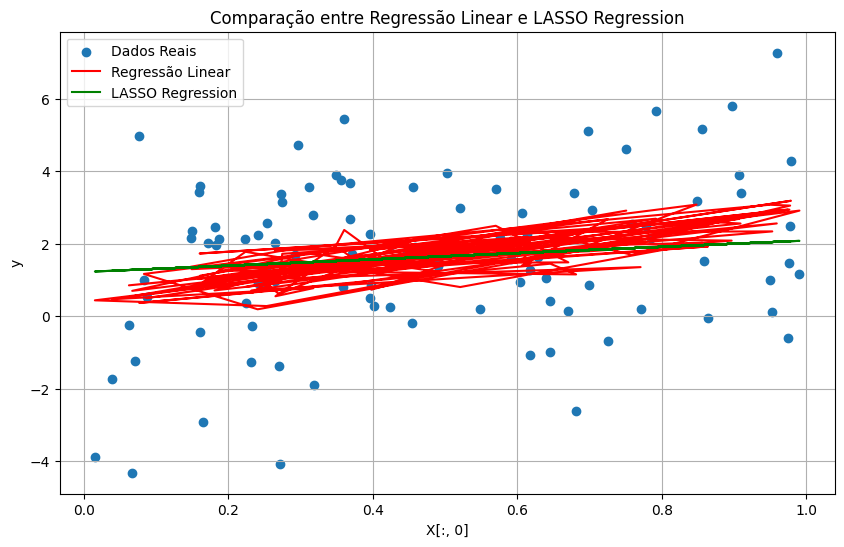

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso

# Generate some sample data with irrelevant features
np.random.seed(0)
X = np.random.rand(100, 5) # 5 features
y = 2 * X[:, 0] + 1.5 * X[:, 1] + np.random.randn(100) * 2 # y depends only on the first 2 features

# Fit a simple linear regression model (no shrinkage)
lr = LinearRegression()
lr.fit(X, y)
print(f"Coeficientes (Regressão Linear): {lr.coef_}")

# Fit a Lasso regression model
# Adjust alpha to see the effect on coefficients
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)
print(f"Coeficientes (LASSO Regression): {lasso.coef_}")

# For a visual example, let's plot against the most important feature (X[:, 0])
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, label='Dados Reais')
plt.plot(X[:, 0], lr.predict(X), color='red', label='Regressão Linear')
plt.plot(X[:, 0], lasso.predict(X), color='green', label='LASSO Regression')
plt.xlabel('X[:, 0]')
plt.ylabel('y')
plt.title('Comparação entre Regressão Linear e LASSO Regression')
plt.legend()
plt.grid(True)
plt.show()

A principal diferença entre LASSO (Least Absolute Shrinkage and Selection Operator) e Ridge Regression (Regularização de Tikhonov) está no tipo de penalidade que cada um adiciona à função de custo e no efeito que essa penalidade tem nos coeficientes do modelo:

1.  **Tipo de Penalidade:**
    *   **Ridge Regression:** Usa a penalidade **L2**, que é a soma dos quadrados dos coeficientes ($\sum \beta_j^2$).
    *   **LASSO:** Usa a penalidade **L1**, que é a soma dos valores absolutos dos coeficientes ($\sum |\beta_j|$).

2.  **Efeito nos Coeficientes:**
    *   **Ridge Regression:** Encolhe os coeficientes em direção a zero, mas **raramente os torna exatamente zero**. Todos os preditores tendem a permanecer no modelo, embora com pesos menores.
    *   **LASSO:** Também encolhe os coeficientes, mas tem a propriedade de levar os coeficientes de preditores menos importantes a **exatamente zero**. Isso realiza a **seleção automática de variáveis**, removendo efetivamente esses preditores do modelo.

3.  **Lidando com Variáveis Correlacionadas:**
    *   **Ridge Regression:** Tende a distribuir o peso entre variáveis altamente correlacionadas.
    *   **LASSO:** Tende a escolher uma das variáveis correlacionadas e zerar as outras.

Em resumo:

*   Use **Ridge** quando você tem muitas variáveis e a maioria delas é relevante, e você quer encolher os coeficientes para reduzir a variância e lidar com multicolinearidade, mas não necessariamente eliminar variáveis.
*   Use **LASSO** quando você suspeita que muitas das suas variáveis são irrelevantes e você quer um modelo mais simples e interpretável, realizando seleção automática de variáveis.

A escolha entre Ridge e LASSO muitas vezes depende do objetivo do seu modelo (previsão vs. interpretabilidade) e das características dos seus dados. A Regularização Elastic Net combina o melhor dos dois mundos, usando uma combinação das penalidades L1 e L2.